In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import plotly as py
import plotly.graph_objs as go

py.offline.init_notebook_mode(connected=True)

%matplotlib inline

In [19]:
data = pd.read_csv("/kaggle/input/datasets/ricardofernandes99/master/Dataset-iGov.csv")
data.head()

,id_registo,data_registo,unidade_organizacional,tipo_servico,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,canal_utilizado,taxa_abandono,erros_tecnicos,transparencia,feedback_cidadao,segmentacao_utilizador,area_tematica,indicador_kpi
0,1,2024-04-12,Direcção De Serviços Financeiros,Telefone,83.02,87.37,36,3.8,368,Presencial,22.41,7,Sim,Processo Complicado,Empresa,Cultura,63.13
1,2,2024-12-14,Departamento De Inovação E Digitalização,Balcão Único,75.53,89.71,29,4.1,349,Email,14.87,1,Sim,Bom Serviço,Funcionário Público,Saúde,63.58
2,3,2024-09-27,Direcção De Recursos Humanos,Chatbot,85.73,75.96,38,3.3,398,Telefone,15.42,5,Não,Processo Complicado,Estudante,Inovação,73.64
3,4,2024-04-16,Departamento De Planeamento Estratégico,Email,78.33,73.82,57,3.4,74,Aplicacao_Movel,15.32,11,Sim,Processo Complicado,Funcionário Público,Digitalização,99.19
4,5,2024-03-12,Direcção De Recursos Humanos,Atendimento Presencial,81.82,70.41,97,4.7,487,Portal,7.47,4,Sim,Serviço Eficiente,Cidadão,Saúde,63.45


In [20]:
data.columns

Index(['id_registo', 'data_registo', 'unidade_organizacional', 'tipo_servico',
       'indicador_si', 'taxa_resolucao', 'tempo_resposta',
       'satisfacao_cidadao', 'volume_interacoes', 'canal_utilizado',
       'taxa_abandono', 'erros_tecnicos', 'transparencia', 'feedback_cidadao',
       'segmentacao_utilizador', 'area_tematica', 'indicador_kpi'],
      dtype='object')

In [21]:
len(data)

200

In [22]:
data.unidade_organizacional.unique()

array(['Direcção De Serviços Financeiros',
       'Departamento De Inovação E Digitalização',
       'Direcção De Recursos Humanos',
       'Departamento De Planeamento Estratégico', 'Serviços De Educação',
       'Gabinete De Atendimento Ao Cidadão', 'Serviços De Ti',
       'Departamento De Saúde Pública'], dtype=object)

In [23]:
data.canal_utilizado.unique()

array(['Presencial', 'Email', 'Telefone', 'Aplicacao_Movel', 'Portal',
       'Chatbot'], dtype=object)

## Dados Estatisticos


In [24]:
num = data.select_dtypes(include=np.number)

stats_summary = pd.DataFrame({
    "n": num.count(),
    "min": num.min(),
    "max": num.max(),
    "moda": num.mode().iloc[0],
    "mediana": num.median(),
    "media": num.mean(),
    "q1 (25%)": num.quantile(0.25),
    "q3 (75%)": num.quantile(0.75),
    "desvio_padrao": num.std()
})

print(stats_summary)

                      n    min     max   moda  mediana      media  q1 (25%)  \
id_registo          200   1.00  200.00   1.00  100.500  100.50000   50.7500   
indicador_si        200  60.43   99.99  63.65   82.390   81.58325   71.3925   
taxa_resolucao      200  70.41   97.72  76.79   82.275   82.90985   75.8400   
tempo_resposta      200   1.00  118.00  29.00   54.500   58.73000   29.7500   
satisfacao_cidadao  200   3.00    5.00   3.50    4.000    3.98550    3.5000   
volume_interacoes   200  12.00  499.00  49.00  251.000  251.59000  131.2500   
taxa_abandono       200   0.23   24.83   8.98   13.325   12.55550    7.8975   
erros_tecnicos      200   0.00   14.00   9.00    7.000    7.03500    3.0000   
indicador_kpi       200  50.11   99.99  52.24   75.475   75.16680   63.0750   

                    q3 (75%)  desvio_padrao  
id_registo          150.2500      57.879185  
indicador_si         92.5575      12.373367  
taxa_resolucao       88.7925       7.769950  
tempo_resposta       88.2

In [25]:
from scipy import stats

normal = {}

for col in num.columns:
    if col == "id_registo":  
        continue
    _, p = stats.shapiro(num[col].dropna())
    normal[col] = {"p": p}

normal = pd.DataFrame(normal).T
print(normal)


                               p
indicador_si        5.944284e-08
taxa_resolucao      1.268948e-06
tempo_resposta      8.183859e-06
satisfacao_cidadao  6.388007e-07
volume_interacoes   2.572206e-06
taxa_abandono       7.590728e-04
erros_tecnicos      3.701614e-06
indicador_kpi       1.230889e-05


In [26]:
data["transparencia_bin"] = data["transparencia"].map({"Sim": 1, "Não": 0})
col_bin = data["transparencia_bin"].dropna()

Número de tentativas (n): 200
Probabilidade de sucesso (p): 0.745


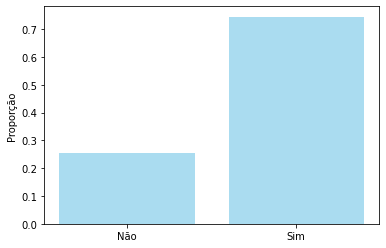

In [27]:

n = len(col_bin)        
p = col_bin.mean()       

print("Número de tentativas (n):", n)
print("Probabilidade de sucesso (p):", p)
proporcoes = col_bin.value_counts(normalize=True).sort_index()
plt.bar(proporcoes.index, proporcoes.values, color="skyblue", alpha=0.7, tick_label=["Não", "Sim"])
plt.ylabel("Proporção")
plt.show()

Lambda: 7.035


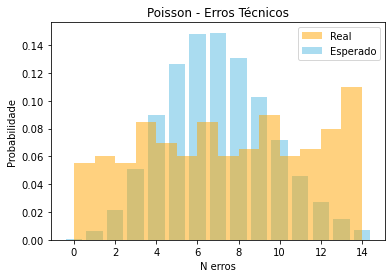

In [32]:
from scipy.stats import poisson

col = data['erros_tecnicos'].dropna()
lambda1 = col.mean()  
print("Lambda:", lambda1)

k = np.arange(0, col.max()+1)
pmf = poisson.pmf(k, lambda1)

plt.bar(k, pmf, alpha=0.7, color="skyblue", label="Esperado")
plt.hist(col, bins=k, density=True, alpha=0.5, color="orange", label="Real")
plt.xlabel("N erros")
plt.ylabel("Probabilidade")
plt.title("Poisson - Erros Técnicos")
plt.legend()
plt.show()


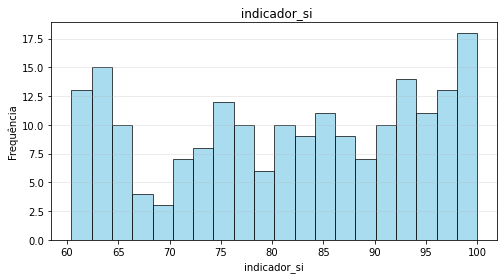

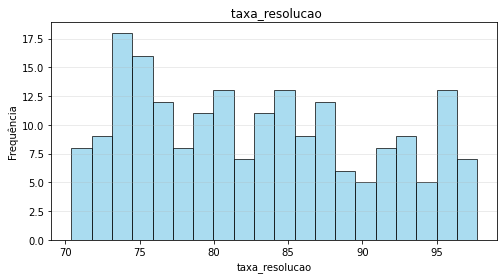

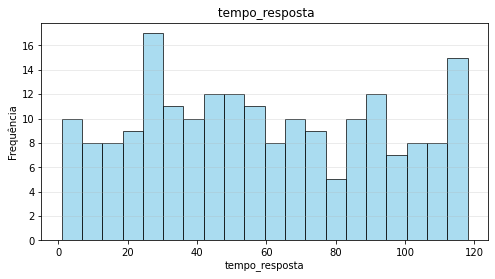

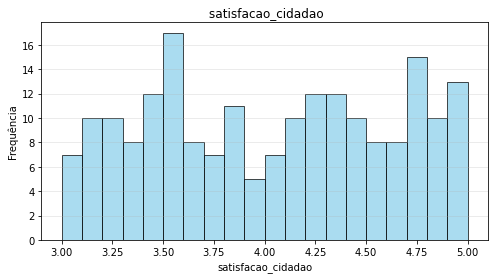

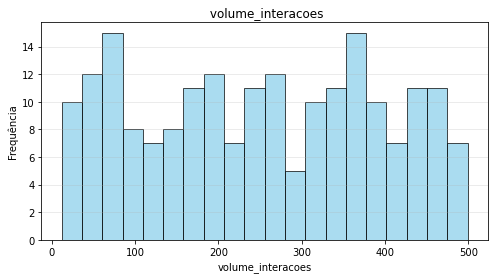

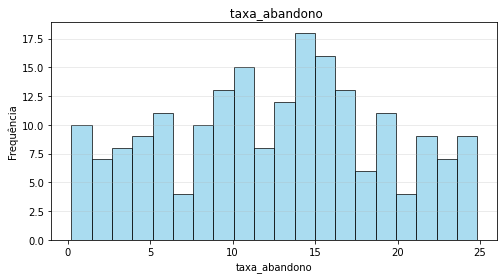

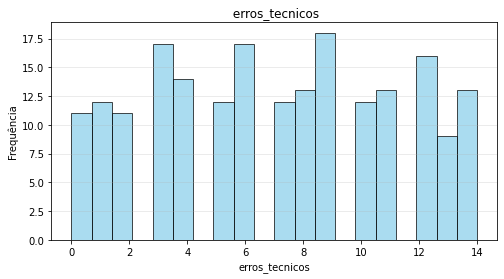

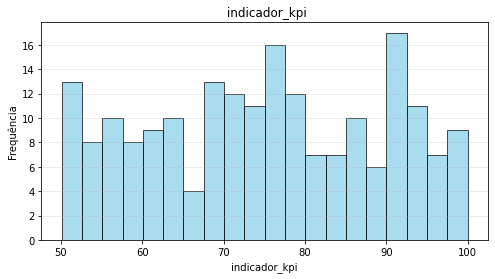

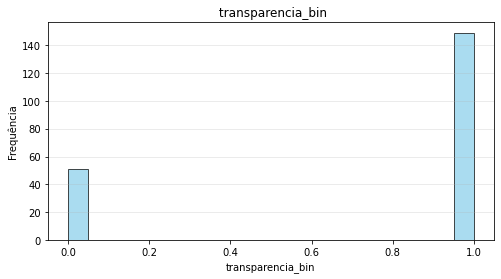

In [33]:
num_cols = data.select_dtypes(include='number').columns

for col in num_cols:
    if col == "id_registo":
        continue
    plt.figure(figsize=(8, 4))
    plt.hist(data[col].dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f" {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.grid(axis='y', alpha=0.3)
    plt.show()


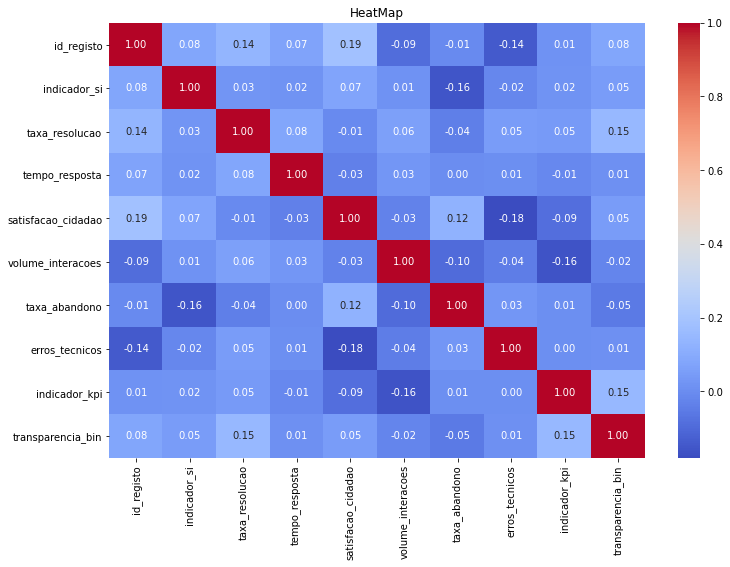

In [34]:
import seaborn as sns


num_cols = data.select_dtypes(include='number')
corr = num_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("HeatMap")
plt.show()


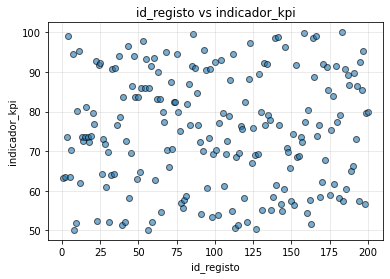

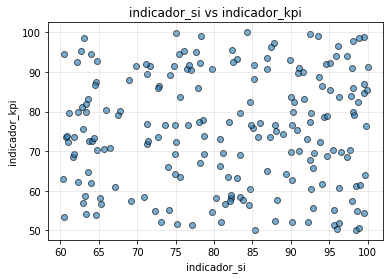

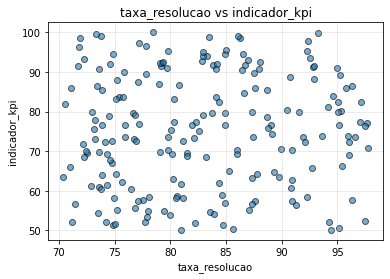

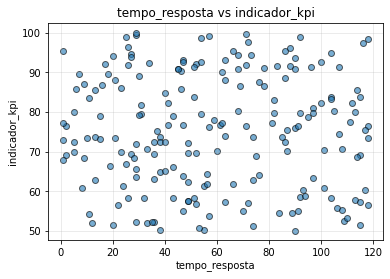

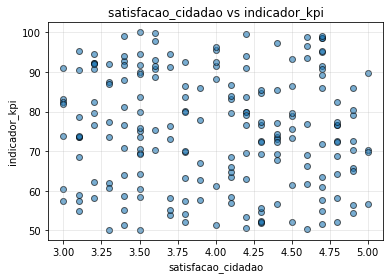

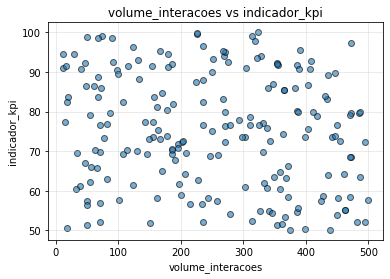

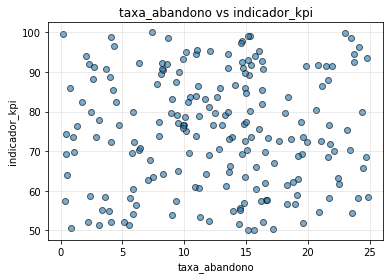

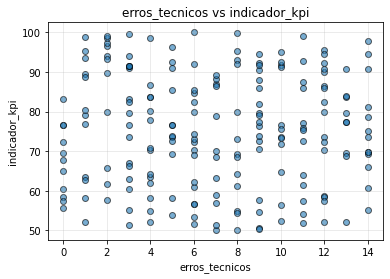

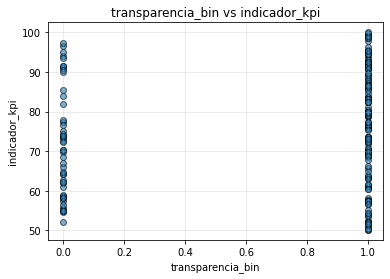

In [35]:

num_cols = data.select_dtypes(include='number').columns
target = 'indicador_kpi'  

for col in num_cols:
    if col == target:
        continue  
    
    plt.figure(figsize=(6,4))
    plt.scatter(data[col], data[target], alpha=0.6, edgecolor='k')
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs {target}")
    plt.grid(True, alpha=0.3)
    plt.show()


In [36]:
%%HTML
<div class='tableauPlaceholder' id='viz1771327815262' style='position: relative'><noscript><a href='#'><img alt='Painel 1 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;AO&#47;AOOP&#47;Painel1&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='AOOP&#47;Painel1' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;AO&#47;AOOP&#47;Painel1&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='pt-BR' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1771327815262');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.io as pio
pio.renderers.default = "iframe_connected"
# Carregar dataset
data = pd.read_csv("/kaggle/input/datasets/ricardofernandes99/master/Dataset-iGov.csv")

# Colunas numéricas
num_cols = ['taxa_resolucao', 'tempo_resposta', 'satisfacao_cidadao',
            'volume_interacoes', 'taxa_abandono', 'erros_tecnicos']

# Garantir numérico e substituir NaNs
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Normalizar
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[num_cols])

# Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
data['cluster'] = kmeans.fit_predict(data_scaled)

# Criar coluna de tamanho para scatter
data['volume_interacoes_plot'] = data['volume_interacoes'].replace(0, 1)

# Scatter interativo
fig = px.scatter(
    data,
    x='tempo_resposta',
    y='satisfacao_cidadao',
    color='cluster',
    size='volume_interacoes_plot',
    hover_data=['tipo_servico', 'unidade_organizacional', 'area_tematica']
)
fig.update_layout(title="Clustering: Tempo de Resposta vs Satisfação")
fig.show()


Silhouette médio: 0.4387466540048461


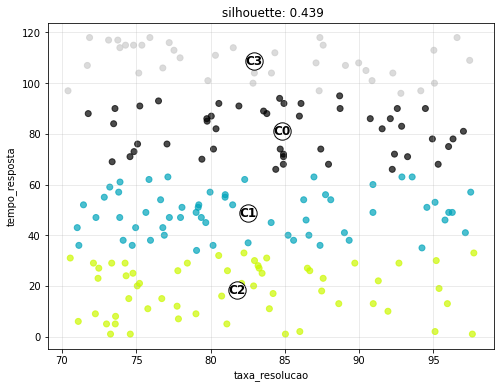

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# carregar dados
data = pd.read_csv("/kaggle/input/datasets/ricardofernandes99/master/Dataset-iGov.csv")

features = ['taxa_resolucao', 'tempo_resposta']

# limpeza
for col in features:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data[features] = data[features].fillna(data[features].mean())

# ❌ REMOVIDA normalização
X = data[features].values

# escolher k
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

silhouette_avg = silhouette_score(X, labels)
print("Silhouette médio:", silhouette_avg)

# -------------------------
# Plot direto (valores reais)
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    cmap='nipy_spectral',
    alpha=0.7
)

# centroides
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='white',
    s=300,
    edgecolor='black'
)

# ✅ adicionar labels nos centroides
for i, center in enumerate(centers):
    plt.text(
        center[0],
        center[1],
        f"C{i}",
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='center'
    )

plt.xlabel('taxa_resolucao')
plt.ylabel('tempo_resposta')
plt.title(f' silhouette: {silhouette_avg:.3f}')

plt.grid(alpha=0.3)
plt.show()


K escolhido : 4


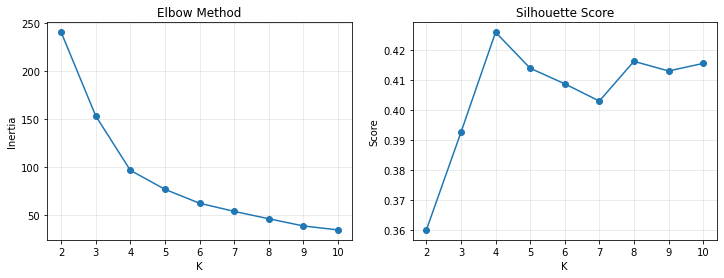

Silhouette médio final: 0.42590800943231955


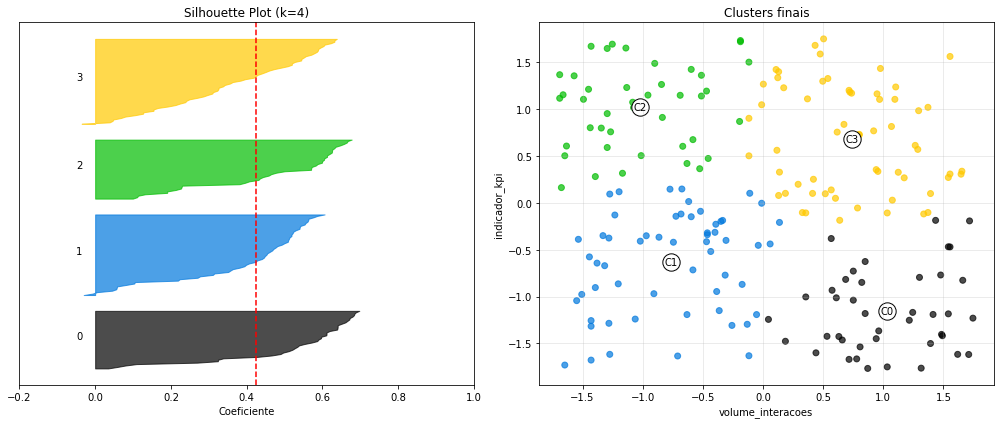

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples


data = pd.read_csv("/kaggle/input/datasets/ricardofernandes99/master/Dataset-iGov.csv")

features = ['volume_interacoes', 'indicador_kpi']

for col in features:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data[features] = data[features].fillna(data[features].mean())

scaler = StandardScaler()
X = scaler.fit_transform(data[features])


inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k_test in K_range:
    km = KMeans(n_clusters=k_test, random_state=42)
    labels_test = km.fit_predict(X)

    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels_test))

k = K_range[np.argmax(silhouette_scores)]

print("K escolhido :", k)

fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(K_range, inertia, marker='o')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inertia")
ax[0].grid(alpha=0.3)

ax[1].plot(K_range, silhouette_scores, marker='o')
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Score")
ax[1].grid(alpha=0.3)

plt.show()

kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

silhouette_avg = silhouette_score(X, labels)
sample_silhouette_values = silhouette_samples(X, labels)

print("Silhouette médio final:", silhouette_avg)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

y_lower = 10

for i in range(k):
    ith_cluster = sample_silhouette_values[labels == i]
    ith_cluster.sort()

    size_cluster = ith_cluster.shape[0]
    y_upper = y_lower + size_cluster

    color = plt.cm.nipy_spectral(float(i) / k)

    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster,
        facecolor=color,
        edgecolor=color,
        alpha=0.7
    )

    ax1.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    y_lower = y_upper + 10

ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_title(f"Silhouette Plot (k={k})")
ax1.set_xlabel("Coeficiente")
ax1.set_yticks([])
ax1.set_xlim([-0.2, 1])

colors = plt.cm.nipy_spectral(labels.astype(float) / k)

ax2.scatter(X[:,0], X[:,1], c=colors, alpha=0.7)

centers = kmeans.cluster_centers_

ax2.scatter(
    centers[:,0],
    centers[:,1],
    c='white',
    s=300,
    edgecolor='black'
)

for i, center in enumerate(centers):
    ax2.text(center[0], center[1], f"C{i}", ha='center', va='center')

ax2.set_title("Clusters finais")
ax2.set_xlabel(features[0])
ax2.set_ylabel(features[1])
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


K escolhido automaticamente: 74


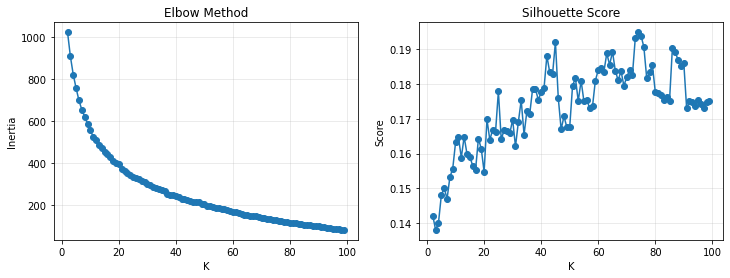

Silhouette médio final: 0.19480578309825775


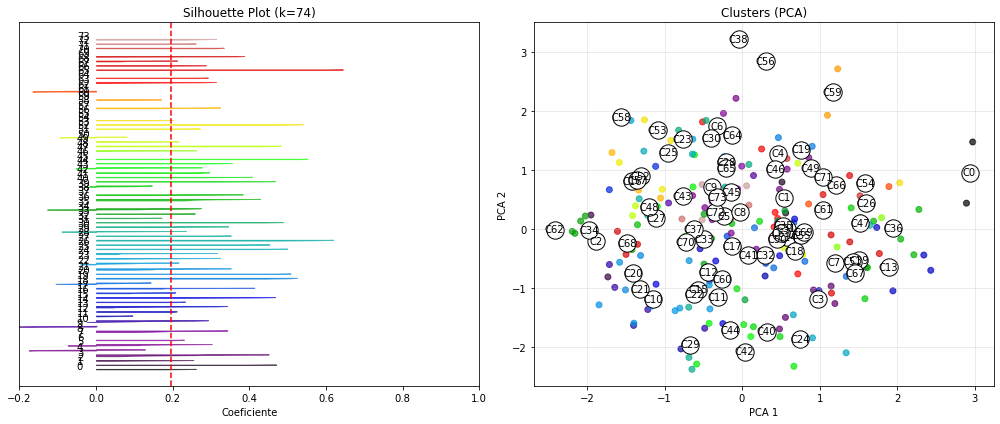

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

# -----------------------------
# Leitura e preparação
# -----------------------------
data = pd.read_csv("/kaggle/input/datasets/ricardofernandes99/master/Dataset-iGov.csv")

features = [
    'taxa_resolucao',
    'tempo_resposta',
    'satisfacao_cidadao',
    'volume_interacoes',
    'taxa_abandono',
    'erros_tecnicos'
]

# limpeza
for col in features:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data[features] = data[features].fillna(data[features].mean())

# normalização
scaler = StandardScaler()
X = scaler.fit_transform(data[features])

# -----------------------------
# Elbow + Silhouette automático
# -----------------------------
inertia = []
silhouette_scores = []
K_range = range(2, 100)

for k_test in K_range:
    km = KMeans(n_clusters=k_test, random_state=42)
    labels_test = km.fit_predict(X)

    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels_test))

k = K_range[np.argmax(silhouette_scores)]

print("K escolhido automaticamente:", k)

# gráficos elbow + silhouette
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(K_range, inertia, marker='o')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inertia")
ax[0].grid(alpha=0.3)

ax[1].plot(K_range, silhouette_scores, marker='o')
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Score")
ax[1].grid(alpha=0.3)

plt.show()

# -----------------------------
# KMeans final
# -----------------------------
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

silhouette_avg = silhouette_score(X, labels)
sample_silhouette_values = silhouette_samples(X, labels)

print("Silhouette médio final:", silhouette_avg)

# -----------------------------
# PCA para visualização 2D
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# -----------------------------
# Visualização silhouette + clusters
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

y_lower = 10

for i in range(k):
    ith_cluster = sample_silhouette_values[labels == i]
    ith_cluster.sort()

    size_cluster = ith_cluster.shape[0]
    y_upper = y_lower + size_cluster

    color = plt.cm.nipy_spectral(float(i) / k)

    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster,
        facecolor=color,
        edgecolor=color,
        alpha=0.7
    )

    ax1.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    y_lower = y_upper + 10

ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_title(f"Silhouette Plot (k={k})")
ax1.set_xlabel("Coeficiente")
ax1.set_yticks([])
ax1.set_xlim([-0.2, 1])

colors = plt.cm.nipy_spectral(labels.astype(float) / k)

ax2.scatter(X_pca[:,0], X_pca[:,1], c=colors, alpha=0.7)

centers = pca.transform(kmeans.cluster_centers_)

ax2.scatter(
    centers[:,0],
    centers[:,1],
    c='white',
    s=300,
    edgecolor='black'
)

for i, center in enumerate(centers):
    ax2.text(center[0], center[1], f"C{i}", ha='center', va='center')

ax2.set_title("Clusters (PCA)")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


=== FREQUENCY TABLE ===
0     51
1    149
Name: transparencia_bin, dtype: int64

Estimated p (P[Transparência=1]): 0.745

Binomial test p-value (H0: p = 0.5): 2.500694805090764e-12


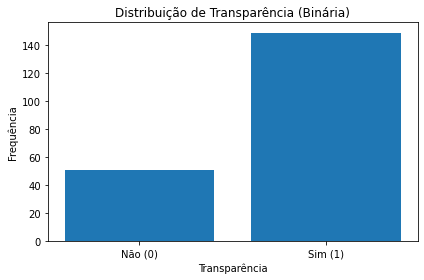

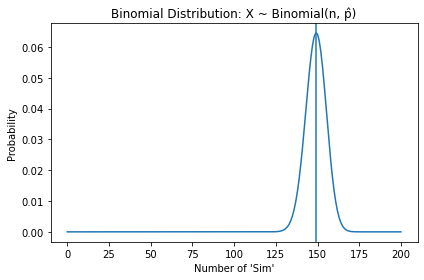

Chi-square p-value: 0.17333464657935205


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom_test

file_path = "/kaggle/input/datasets/ricardofernandes99/master/Dataset-iGov.csv"
df = pd.read_csv(file_path)

# Convert 'transparencia' to binary (Sim=1, Não=0)
df["transparencia_bin"] = df["transparencia"].map({"Sim": 1, "Não": 0})

# Frequency table
counts = df["transparencia_bin"].value_counts().sort_index()
n = len(df)
successes = counts.get(1, 0)
failures = counts.get(0, 0)

print("=== FREQUENCY TABLE ===")
print(counts)

# Estimated probability p
p_hat = successes / n
print("\nEstimated p (P[Transparência=1]):", p_hat)

# Binomial test against p = 0.5 (null hypothesis)
p_value = binom_test(successes, n, 0.5, alternative='two-sided')
print("\nBinomial test p-value (H0: p = 0.5):", p_value)

# Plot distribution (single plot, no specific colors)
plt.figure()
plt.bar(counts.index, counts.values)
plt.xticks([0,1], ["Não (0)", "Sim (1)"])
plt.title("Distribuição de Transparência (Binária)")
plt.xlabel("Transparência")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

from scipy.stats import binom

# Range of possible successes
k = np.arange(0, n+1)

# Theoretical binomial probabilities
binom_pmf = binom.pmf(k, n, p_hat)

plt.figure()
plt.plot(k, binom_pmf)
plt.axvline(successes)
plt.title("Binomial Distribution: X ~ Binomial(n, p̂)")
plt.xlabel("Number of 'Sim'")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["unidade_organizacional"], df["transparencia_bin"])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square p-value:", p)

In [1]:
import os
import uuid
import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.io import to_html
from scipy.stats import shapiro, poisson
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from IPython.display import HTML, display

# =========================================================
# 1) LOAD DATA
# =========================================================
possible_paths = [
    "Dataset-iGov.csv",
    "/kaggle/input/datasets/ricardofernandes99/master/Dataset-iGov.csv",
    "/mnt/data/Dataset-iGov.csv"
]

data_path = next((p for p in possible_paths if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError(
        "Dataset-iGov.csv not found. Put it in the notebook folder or update 'possible_paths'."
    )

df = pd.read_csv(data_path)

# =========================================================
# 2) PREP
# =========================================================
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if "id_registo" in numeric_cols:
    numeric_cols.remove("id_registo")

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

target_col = "indicador_kpi" if "indicador_kpi" in df.columns else numeric_cols[-1]

# Theme
BG = "#f5f7fb"
CARD = "#ffffff"
TEXT = "#0f172a"
SUBT = "#475569"
GRID = "#e2e8f0"
BORDER = "#dbe3ef"
PRIMARY = "#5b6cff"
PRIMARY_SOFT = "#eef2ff"
GREEN = "#10b981"
ORANGE = "#f59e0b"
RED = "#ef4444"
PURPLE = "#8b5cf6"
CYAN = "#06b6d4"

palette = [
    PRIMARY, PURPLE, GREEN, ORANGE, CYAN, "#ec4899", "#22c55e", "#f97316"
]

def apply_layout(fig, height=420, showlegend=False):
    fig.update_layout(
        template="plotly_white",
        paper_bgcolor=CARD,
        plot_bgcolor=CARD,
        font=dict(color=TEXT, family="Arial"),
        margin=dict(t=25, r=20, b=40, l=50),
        height=height,
        showlegend=showlegend,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.2,
            xanchor="left",
            x=0
        )
    )
    fig.update_xaxes(showgrid=True, gridcolor=GRID, zeroline=False)
    fig.update_yaxes(showgrid=True, gridcolor=GRID, zeroline=False)
    return fig

# ---------------------------------------------------------
# IMPORTANT: wrap plotly HTML to force correct sizing in browser
# ---------------------------------------------------------
def fig_to_div(fig, include_js=False):
    inner = to_html(
        fig,
        include_plotlyjs="inline" if include_js else False,
        full_html=False,
        config={"displayModeBar": False, "responsive": True},
        default_width="100%",
        default_height="100%"
    )
    return f'<div class="plotly-wrap">{inner}</div>'

def make_card(title, subtitle, body_html, min_height="420px"):
    return f"""
    <div class="dash-card" style="min-height:{min_height};">
        <div class="card-head">
            <div class="card-title">{title}</div>
            <div class="card-subtitle">{subtitle}</div>
        </div>
        <div class="card-body">
            {body_html}
        </div>
    </div>
    """

# =========================================================
# 3) STATS / TESTS
# =========================================================
stats_df = pd.DataFrame({
    "N": df[numeric_cols].count(),
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max(),
    "Moda": [df[c].mode().iloc[0] if not df[c].mode().empty else np.nan for c in numeric_cols],
    "Mediana": df[numeric_cols].median(),
    "Média": df[numeric_cols].mean(),
    "Q1": df[numeric_cols].quantile(0.25),
    "Q3": df[numeric_cols].quantile(0.75),
    "Desvio Padrão": df[numeric_cols].std()
}).round(3)

normality_rows = []
for col in numeric_cols:
    vals = df[col].dropna()
    if len(vals) > 5000:
        vals = vals.sample(5000, random_state=42)
    if len(vals) < 3:
        p = np.nan
    else:
        _, p = shapiro(vals)
    normality_rows.append([col, None if pd.isna(p) else round(float(p), 6), "Sim" if (not pd.isna(p) and p > 0.05) else "Não"])

normality_df = pd.DataFrame(
    normality_rows, columns=["Variável", "p-value", "Normal? (0.05)"]
)

# Transparência
if "transparencia" in df.columns:
    df["transparencia_bin"] = df["transparencia"].map({"Sim": 1, "Não": 0})
    trans_counts = df["transparencia_bin"].value_counts().sort_index()
    p_hat = float(df["transparencia_bin"].mean())
else:
    trans_counts = pd.Series([0, 0], index=[0, 1])
    p_hat = 0.0

# Poisson for erros_tecnicos
if "erros_tecnicos" in df.columns:
    erros = df["erros_tecnicos"].dropna()
    lambda_val = float(erros.mean())
    max_k = int(erros.max()) if len(erros) else 0
    k_vals = np.arange(0, max_k + 1)
    pmf_vals = poisson.pmf(k_vals, lambda_val)

    obs_counts = erros.value_counts().sort_index()
    obs_probs = np.array([obs_counts.get(k, 0) for k in k_vals], dtype=float)
    obs_probs = obs_probs / obs_probs.sum() if obs_probs.sum() > 0 else obs_probs
else:
    erros = pd.Series(dtype=float)
    lambda_val = 0.0
    k_vals = np.array([0])
    pmf_vals = np.array([0.0])
    obs_probs = np.array([0.0])

# Correlation
corr = df[numeric_cols].corr().round(2)

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

top_pos = corr_pairs.sort_values("Correlation", ascending=False).head(4)
top_neg = corr_pairs.sort_values("Correlation", ascending=True).head(4)

top_corr_df = (
    pd.concat([top_pos, top_neg], ignore_index=True)
      .round(3)
      .reset_index(drop=True)
)

# =========================================================
# 4) CLUSTERING
# =========================================================
cluster_features = ["volume_interacoes", "indicador_kpi"]
cluster_features = [c for c in cluster_features if c in df.columns]
if len(cluster_features) < 2:
    cluster_features = numeric_cols[:2]

cluster_df = df[cluster_features].copy()
for col in cluster_features:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors="coerce")

cluster_df[cluster_features] = cluster_df[cluster_features].fillna(cluster_df[cluster_features].mean())

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df[cluster_features])

inertia = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_cluster)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels_k))

best_k = list(k_range)[int(np.argmax(sil_scores))]

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)
centers = kmeans.cluster_centers_

best_sil = float(silhouette_score(X_cluster, cluster_labels))
sample_silhouette_values = silhouette_samples(X_cluster, cluster_labels)

# =========================================================
# 5) FIGURES
# =========================================================

# ---- Stats table
fig_stats = go.Figure(data=[go.Table(
    columnwidth=[140] + [90] * len(stats_df.columns),
    header=dict(
        values=["<b>Variável</b>"] + [f"<b>{c}</b>" for c in stats_df.columns],
        fill_color=PRIMARY,
        font=dict(color="white", size=12),
        align="center",
        height=34,
        line_color=BORDER
    ),
    cells=dict(
        values=[stats_df.index.tolist()] + [stats_df[c].tolist() for c in stats_df.columns],
        fill_color="white",
        font=dict(color=TEXT, size=11),
        align="center",
        height=30,
        line_color=BORDER
    )
)])
fig_stats.update_layout(paper_bgcolor=CARD, margin=dict(t=10, r=10, b=10, l=10), height=360)

# ---- Normality table
fig_normality = go.Figure(data=[go.Table(
    header=dict(
        values=[f"<b>{c}</b>" for c in normality_df.columns],
        fill_color=PURPLE,
        font=dict(color="white", size=12),
        align="center",
        height=34,
        line_color=BORDER
    ),
    cells=dict(
        values=[normality_df[c].tolist() for c in normality_df.columns],
        fill_color="white",
        font=dict(color=TEXT, size=11),
        align="center",
        height=30,
        line_color=BORDER
    )
)])
fig_normality.update_layout(paper_bgcolor=CARD, margin=dict(t=10, r=10, b=10, l=10), height=360)

# ---- Transparency bar
fig_transparency = go.Figure()
fig_transparency.add_trace(go.Bar(
    x=["Não", "Sim"],
    y=[trans_counts.get(0, 0), trans_counts.get(1, 0)],
    text=[trans_counts.get(0, 0), trans_counts.get(1, 0)],
    textposition="outside",
    marker=dict(color=[ORANGE, PRIMARY], line=dict(width=1, color="white")),
    hovertemplate="Categoria: %{x}<br>Frequência: %{y}<extra></extra>"
))
fig_transparency.update_xaxes(title="Transparência")
fig_transparency.update_yaxes(title="Frequência")
apply_layout(fig_transparency, height=330)

# ---- Poisson overlay
fig_poisson = go.Figure()
fig_poisson.add_trace(go.Bar(
    x=k_vals,
    y=pmf_vals,
    name="Poisson teórica",
    marker=dict(color=PRIMARY, line=dict(width=1, color="white")),
    opacity=0.75,
    hovertemplate="Erros: %{x}<br>Probabilidade: %{y:.4f}<extra></extra>"
))
fig_poisson.add_trace(go.Bar(
    x=k_vals,
    y=obs_probs,
    name="Distribuição observada",
    marker=dict(color=ORANGE, line=dict(width=1, color="white")),
    opacity=0.55,
    hovertemplate="Erros: %{x}<br>Probabilidade: %{y:.4f}<extra></extra>"
))
fig_poisson.update_layout(barmode="overlay")
fig_poisson.update_xaxes(title="Nº de erros técnicos")
fig_poisson.update_yaxes(title="Probabilidade")
apply_layout(fig_poisson, height=330, showlegend=True)

# ---- Histograms grid (with outlines)
hist_cols = numeric_cols[:]
hist_cols_per_row = 2
hist_rows = int(np.ceil(len(hist_cols) / hist_cols_per_row))

fig_hists = make_subplots(
    rows=hist_rows,
    cols=hist_cols_per_row,
    subplot_titles=hist_cols,
    vertical_spacing=0.09,
    horizontal_spacing=0.08
)

for i, col in enumerate(hist_cols):
    r = i // hist_cols_per_row + 1
    c = i % hist_cols_per_row + 1
    fig_hists.add_trace(
        go.Histogram(
            x=df[col].dropna(),
            nbinsx=20,
            marker=dict(color=palette[i % len(palette)], line=dict(width=1, color="white")),
            showlegend=False,
            hovertemplate=f"{col}<br>Valor: %{{x}}<br>Frequência: %{{y}}<extra></extra>"
        ),
        row=r, col=c
    )

apply_layout(fig_hists, height=max(420, 220 * hist_rows))
fig_hists.update_annotations(font=dict(size=12, color=TEXT))

# ---- Correlation heatmap (slightly smaller)
fig_corr = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=corr.columns,
    y=corr.index,
    colorscale="RdBu_r",
    zmin=-1,
    zmax=1,
    colorbar=dict(thickness=12),
    hovertemplate="X: %{x}<br>Y: %{y}<br>Correlação: %{z}<extra></extra>"
))
heat_annotations = []
for i, y_name in enumerate(corr.index):
    for j, x_name in enumerate(corr.columns):
        val = corr.iloc[i, j]
        heat_annotations.append(
            dict(
                x=x_name,
                y=y_name,
                text=str(val),
                showarrow=False,
                font=dict(size=10, color="white" if abs(val) >= 0.5 else TEXT)
            )
        )
fig_corr.update_layout(annotations=heat_annotations)
apply_layout(fig_corr, height=420)

# ---- Strongest correlation table
fig_topcorr = go.Figure(data=[go.Table(
    columnwidth=[200, 200, 120],
    header=dict(
        values=["<b>Feature 1</b>", "<b>Feature 2</b>", "<b>Correlation</b>"],
        fill_color=GREEN,
        font=dict(color="white", size=13),
        align="center",
        height=40,
        line_color=BORDER
    ),
    cells=dict(
        values=[
            top_corr_df["Feature 1"].tolist(),
            top_corr_df["Feature 2"].tolist(),
            top_corr_df["Correlation"].tolist()
        ],
        fill_color="white",
        font=dict(color=TEXT, size=12),
        align="center",
        height=36,
        line_color=BORDER
    )
)])
fig_topcorr.update_layout(paper_bgcolor=CARD, margin=dict(t=10, r=10, b=10, l=10), height=360)

# ---- Cluster scatter (standardized 2D)
fig_cluster = go.Figure()
for cl in sorted(np.unique(cluster_labels)):
    mask = cluster_labels == cl
    fig_cluster.add_trace(go.Scatter(
        x=X_cluster[mask, 0],
        y=X_cluster[mask, 1],
        mode="markers",
        name=f"Cluster {cl}",
        marker=dict(size=9, color=palette[int(cl) % len(palette)], opacity=0.82, line=dict(width=0.5, color="white")),
        hovertemplate=(
            f"{cluster_features[0]} (std): %{{x:.2f}}<br>"
            f"{cluster_features[1]} (std): %{{y:.2f}}<br>"
            f"Cluster: {cl}<extra></extra>"
        )
    ))

fig_cluster.add_trace(go.Scatter(
    x=centers[:, 0],
    y=centers[:, 1],
    mode="markers+text",
    text=[f"C{i}" for i in range(len(centers))],
    textposition="middle center",
    name="Centroides",
    marker=dict(size=22, color="white", line=dict(color=TEXT, width=2)),
    textfont=dict(color=TEXT, size=11)
))
fig_cluster.update_xaxes(title=f"{cluster_features[0]} (standardized)")
fig_cluster.update_yaxes(title=f"{cluster_features[1]} (standardized)")
apply_layout(fig_cluster, height=430, showlegend=True)

# ---- Elbow + silhouette score
fig_cluster_quality = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Elbow Method", "Silhouette Score"],
    horizontal_spacing=0.14
)
fig_cluster_quality.add_trace(go.Scatter(
    x=list(k_range), y=inertia, mode="lines+markers",
    line=dict(color=PRIMARY, width=3), marker=dict(size=8),
    showlegend=False,
    hovertemplate="K: %{x}<br>Inertia: %{y:.2f}<extra></extra>"
), row=1, col=1)

fig_cluster_quality.add_trace(go.Scatter(
    x=list(k_range), y=sil_scores, mode="lines+markers",
    line=dict(color=GREEN, width=3), marker=dict(size=8),
    showlegend=False,
    hovertemplate="K: %{x}<br>Silhouette: %{y:.4f}<extra></extra>"
), row=1, col=2)

fig_cluster_quality.add_vline(x=best_k, line_dash="dash", line_color=RED, row=1, col=1)
fig_cluster_quality.add_vline(x=best_k, line_dash="dash", line_color=RED, row=1, col=2)

fig_cluster_quality.update_xaxes(title="K", row=1, col=1)
fig_cluster_quality.update_xaxes(title="K", row=1, col=2)
fig_cluster_quality.update_yaxes(title="Inertia", row=1, col=1)
fig_cluster_quality.update_yaxes(title="Silhouette", row=1, col=2)
apply_layout(fig_cluster_quality, height=360)
fig_cluster_quality.update_annotations(font=dict(size=12, color=TEXT))

# ---- Silhouette plot (clean)
fig_silhouette = go.Figure()
y_lower = 10
gap = 12
unique_clusters = sorted(np.unique(cluster_labels))

for i, cl in enumerate(unique_clusters):
    vals = sample_silhouette_values[cluster_labels == cl]
    vals.sort()
    size_cluster = vals.shape[0]
    y_upper = y_lower + size_cluster
    y_range = np.arange(y_lower, y_upper)

    fig_silhouette.add_trace(go.Scatter(
        x=vals,
        y=y_range,
        mode="lines",
        line=dict(width=0.6, color=palette[i % len(palette)]),
        fill="tozerox",
        name=f"Cluster {cl}",
        hovertemplate="Silhouette: %{x:.3f}<extra></extra>"
    ))

    fig_silhouette.add_annotation(
        x=-0.12,
        y=y_lower + 0.5 * size_cluster,
        text=f"{cl}",
        showarrow=False,
        font=dict(size=12, color=TEXT)
    )

    y_lower = y_upper + gap

fig_silhouette.add_vline(x=best_sil, line_dash="dash", line_color=RED)
fig_silhouette.update_xaxes(title="Silhouette coefficient", range=[-0.2, 1.0], zeroline=True, zerolinecolor=GRID)
fig_silhouette.update_yaxes(title="", showticklabels=False)
apply_layout(fig_silhouette, height=520, showlegend=True)

# =========================================================
# 5.5) SCATTER (UI CONTROLS OUTSIDE PLOT)
# =========================================================
scatter_features = [c for c in numeric_cols if c in df.columns]
if len(scatter_features) < 2:
    scatter_features = numeric_cols[:2]

default_x = scatter_features[0]
default_y = scatter_features[1]

fig_scatter = go.Figure()
pair_to_trace_idx = {}
trace_idx = 0

for i, xcol in enumerate(scatter_features):
    for j, ycol in enumerate(scatter_features):
        if xcol == ycol:
            continue

        fig_scatter.add_trace(go.Scatter(
            x=df[xcol],
            y=df[ycol],
            mode="markers",
            marker=dict(
                size=8,
                color=PRIMARY,
                opacity=0.75,
                line=dict(width=0.5, color="white")
            ),
            visible=(xcol == default_x and ycol == default_y),
            hovertemplate=f"{xcol}: %{{x}}<br>{ycol}: %{{y}}<extra></extra>"
        ))

        pair_to_trace_idx[f"{xcol}||{ycol}"] = trace_idx
        trace_idx += 1

fig_scatter.update_xaxes(title=default_x, showline=True, linewidth=1, linecolor=BORDER)
fig_scatter.update_yaxes(title=default_y, showline=True, linewidth=1, linecolor=BORDER)

# IMPORTANT: tighter top margin (controls are in HTML, not plot)
fig_scatter.update_layout(margin=dict(t=10, r=25, b=55, l=70))
apply_layout(fig_scatter, height=560)

# =========================================================
# 6) KPI HTML
# =========================================================
def safe_mean(colname):
    return float(df[colname].mean()) if colname in df.columns else float("nan")

mean_tempo_resposta = safe_mean("tempo_resposta")
mean_taxa_abandono = safe_mean("taxa_abandono")

kpi_cards_html = f"""
<div class="kpi-grid">
    <div class="kpi-card">
        <div class="kpi-label">Nº Registos</div>
        <div class="kpi-value">{len(df):,}</div>
        <div class="kpi-meta">dataset size</div>
    </div>

    <div class="kpi-card">
        <div class="kpi-label">Média KPI</div>
        <div class="kpi-value">{df[target_col].mean():.2f}</div>
        <div class="kpi-meta">{target_col}</div>
    </div>

    <div class="kpi-card">
        <div class="kpi-label">Média Satisfação</div>
        <div class="kpi-value">{safe_mean("satisfacao_cidadao"):.2f}</div>
        <div class="kpi-meta">satisfacao_cidadao</div>
    </div>

    <div class="kpi-card">
        <div class="kpi-label">Média Resolução</div>
        <div class="kpi-value">{safe_mean("taxa_resolucao"):.2f}</div>
        <div class="kpi-meta">taxa_resolucao</div>
    </div>

    <div class="kpi-card">
        <div class="kpi-label">Média Tempo Resposta</div>
        <div class="kpi-value">{mean_tempo_resposta:.2f}</div>
        <div class="kpi-meta">tempo_resposta</div>
    </div>

    <div class="kpi-card">
        <div class="kpi-label">Média Taxa Abandono</div>
        <div class="kpi-value">{mean_taxa_abandono:.2f}</div>
        <div class="kpi-meta">taxa_abandono</div>
    </div>
</div>
"""

# =========================================================
# 7) FIGURES TO HTML
# =========================================================
overview_stats_div = fig_to_div(fig_stats, include_js=True)
overview_norm_div = fig_to_div(fig_normality)
overview_trans_div = fig_to_div(fig_transparency)
overview_pois_div = fig_to_div(fig_poisson)

dist_hists_div = fig_to_div(fig_hists)

corr_heat_div = fig_to_div(fig_corr)
corr_top_div = fig_to_div(fig_topcorr)
corr_cluster_div = fig_to_div(fig_cluster)
corr_quality_div = fig_to_div(fig_cluster_quality)
corr_silhouette_div = fig_to_div(fig_silhouette)

# Scatter div (special handling)
scatter_plot_div = fig_to_div(fig_scatter)

# =========================================================
# 8) BUILD DASHBOARD HTML
# =========================================================
dashboard_id = f"dash_{uuid.uuid4().hex[:8]}"

# IDs for scatter UI controls
scatter_x_id = f"{dashboard_id}_scatter_x"
scatter_y_id = f"{dashboard_id}_scatter_y"
scatter_plot_container_id = f"{dashboard_id}_scatter_plot"

pair_map_json = json.dumps(pair_to_trace_idx)
features_json = json.dumps(scatter_features)

scatter_card_html = f"""
<div class="dash-card" style="min-height:560px;">
  <div class="card-head">
    <div class="card-title">Scatter analysis</div>
  </div>

  <div class="card-body">
    <div class="scatter-controls">
      <div class="ctrl">
        <span class="ctrl-label">X:</span>
        <select id="{scatter_x_id}" class="ctrl-select"></select>
      </div>

      <div class="ctrl">
        <span class="ctrl-label">Y:</span>
        <select id="{scatter_y_id}" class="ctrl-select"></select>
      </div>
    </div>

    <div id="{scatter_plot_container_id}">
      {scatter_plot_div}
    </div>
  </div>
</div>
"""

html = f"""
<style>
    #{dashboard_id} {{
        font-family: Arial, sans-serif;
        background: {BG};
        color: {TEXT};
        border: 1px solid {BORDER};
        border-radius: 20px;
        overflow: hidden;
    }}

    #{dashboard_id} .dash-shell {{
        display: grid;
        grid-template-columns: 220px 1fr;
        min-height: 900px;
    }}

    #{dashboard_id} .sidebar {{
        background: linear-gradient(180deg, #ffffff 0%, #f8fbff 100%);
        border-right: 1px solid {BORDER};
        padding: 22px 16px;
    }}

    #{dashboard_id} .brand {{
        display: flex;
        gap: 12px;
        align-items: center;
        margin-bottom: 26px;
    }}

    #{dashboard_id} .brand-icon {{
        width: 42px;
        height: 42px;
        border-radius: 12px;
        background: {PRIMARY};
        color: white;
        display: flex;
        align-items: center;
        justify-content: center;
        font-weight: 700;
        font-size: 20px;
        box-shadow: 0 10px 25px rgba(91,108,255,0.18);
    }}

    #{dashboard_id} .brand-title {{
        font-size: 22px;
        font-weight: 700;
        margin-bottom: 4px;
    }}

    #{dashboard_id} .nav-title {{
        color: {SUBT};
        font-size: 12px;
        text-transform: uppercase;
        letter-spacing: .08em;
        margin: 18px 10px 10px;
    }}

    #{dashboard_id} .nav-btn {{
        width: 100%;
        border: 1px solid transparent;
        background: transparent;
        padding: 12px 14px;
        border-radius: 14px;
        text-align: left;
        font-size: 15px;
        color: {TEXT};
        cursor: pointer;
        margin-bottom: 8px;
        transition: .2s ease;
        font-weight: 600;
    }}

    #{dashboard_id} .nav-btn:hover {{
        background: #f8fafc;
        border-color: {BORDER};
    }}

    #{dashboard_id} .nav-btn.active {{
        background: {PRIMARY_SOFT};
        color: {PRIMARY};
        border-color: #c7d2fe;
        box-shadow: inset 0 0 0 1px #c7d2fe;
    }}

    #{dashboard_id} .main {{
        padding: 22px;
    }}

    #{dashboard_id} .topbar {{
        display: flex;
        justify-content: space-between;
        align-items: center;
        gap: 14px;
        margin-bottom: 18px;
    }}

    #{dashboard_id} .topbar h2 {{
        margin: 0;
        font-size: 28px;
    }}

    #{dashboard_id} .topbar p {{
        margin: 6px 0 0;
        color: {SUBT};
        font-size: 14px;
    }}

    #{dashboard_id} .section {{
        display: none;
    }}

    #{dashboard_id} .section.active {{
        display: block;
    }}

    #{dashboard_id} .kpi-grid {{
        display: grid;
        grid-template-columns: repeat(3, minmax(0, 1fr));
        gap: 16px;
        margin-bottom: 18px;
    }}

    #{dashboard_id} .kpi-card {{
        background: white;
        border: 1px solid {BORDER};
        border-radius: 18px;
        padding: 18px;
        box-shadow: 0 8px 24px rgba(15,23,42,0.04);
    }}

    #{dashboard_id} .kpi-label {{
        color: {SUBT};
        font-size: 13px;
        margin-bottom: 10px;
    }}

    #{dashboard_id} .kpi-value {{
        font-size: 30px;
        font-weight: 700;
        color: {TEXT};
        line-height: 1.1;
        margin-bottom: 6px;
    }}

    #{dashboard_id} .kpi-meta {{
        font-size: 12px;
        color: {PRIMARY};
        font-weight: 600;
    }}

    #{dashboard_id} .grid-two {{
        display: grid;
        grid-template-columns: 1fr 1fr;
        gap: 16px;
        margin-bottom: 16px;
    }}

    #{dashboard_id} .grid-one {{
        display: grid;
        grid-template-columns: 1fr;
        gap: 16px;
        margin-bottom: 16px;
    }}

    #{dashboard_id} .dash-card {{
        background: white;
        border: 1px solid {BORDER};
        border-radius: 20px;
        padding: 18px;
        box-shadow: 0 8px 24px rgba(15,23,42,0.04);
        overflow: hidden;
    }}

    #{dashboard_id} .card-head {{
        margin-bottom: 10px;
    }}

    #{dashboard_id} .card-title {{
        font-size: 16px;
        font-weight: 700;
        color: {TEXT};
        margin-bottom: 4px;
    }}

    #{dashboard_id} .card-subtitle {{
        color: {SUBT};
        font-size: 13px;
    }}

    #{dashboard_id} .card-body {{
        width: 100%;
        overflow-x: auto;
        overflow-y: hidden;
    }}

    #{dashboard_id} .plotly-wrap {{
        width: 100%;
        height: 100%;
    }}
    #{dashboard_id} .plotly-wrap .plotly-graph-div {{
        width: 100% !important;
        height: 100% !important;
    }}

    /* ✅ NEW: scatter control styling */
    #{dashboard_id} .scatter-controls {{
        display: flex;
        justify-content: center;
        align-items: center;
        gap: 14px;              /* small gap like you want */
        margin: 2px 0 8px 0;    /* almost no empty space */
        padding: 0;
    }}

    #{dashboard_id} .scatter-controls .ctrl {{
        display: flex;
        align-items: center;
        gap: 8px;
        background: #ffffff;
        border: 1px solid {BORDER};
        border-radius: 12px;
        padding: 6px 10px;
        box-shadow: 0 6px 14px rgba(15,23,42,0.03);
    }}

    #{dashboard_id} .ctrl-label {{
        color: {SUBT};
        font-size: 13px;
        font-weight: 700;
    }}

    #{dashboard_id} .ctrl-select {{
        border: none;
        outline: none;
        font-size: 13px;
        font-weight: 600;
        background: transparent;
        color: {TEXT};
        padding: 4px 6px;
        cursor: pointer;
    }}

    @media (max-width: 1100px) {{
        #{dashboard_id} .dash-shell {{
            grid-template-columns: 1fr;
        }}

        #{dashboard_id} .sidebar {{
            border-right: none;
            border-bottom: 1px solid {BORDER};
        }}

        #{dashboard_id} .kpi-grid,
        #{dashboard_id} .grid-two {{
            grid-template-columns: 1fr;
        }}
    }}
</style>

<div id="{dashboard_id}">
    <div class="dash-shell">
        <aside class="sidebar">
            <div class="brand">
                <div class="brand-icon">▥</div>
                <div>
                    <div class="brand-title">Dashboard</div>
                </div>
            </div>

            <button class="nav-btn active" onclick="showSection_{dashboard_id}('overview', this)">Overview</button>
            <button class="nav-btn" onclick="showSection_{dashboard_id}('distributions', this)">Distributions</button>
            <button class="nav-btn" onclick="showSection_{dashboard_id}('correlations', this)">Correlations & Clustering</button>
            <button class="nav-btn" onclick="showSection_{dashboard_id}('scatter', this)">ScatterPlot</button>
        </aside>

        <main class="main">
            <div class="topbar">
                <div>
                    <h2>Statistical Analysis Dashboard</h2>
                </div>
            </div>

            <section id="{dashboard_id}_overview" class="section active">
                {kpi_cards_html}

                <div class="grid-two">
                    {make_card("Descriptive statistics", "", overview_stats_div, "470px")}
                    {make_card("Normality test", "", overview_norm_div, "470px")}
                </div>

                <div class="grid-two">
                    {make_card("Transparency distribution", "", overview_trans_div, "430px")}
                    {make_card("Poisson fit for erros_tecnicos", "Observed distribution vs theoretical Poisson.", overview_pois_div, "430px")}
                </div>
            </section>

            <section id="{dashboard_id}_distributions" class="section">
                <div class="grid-one">
                    {make_card("Numeric distributions", "Histograms for all numeric columns already explored in your notebook.", dist_hists_div, "980px")}
                </div>
            </section>

            <section id="{dashboard_id}_scatter" class="section">
                <div class="grid-one">
                    {scatter_card_html}
                </div>
            </section>

            <section id="{dashboard_id}_correlations" class="section">
                <div class="grid-two">
                    {make_card("Correlation heatmap", "", corr_heat_div, "420px")}
                    {make_card("Strongest correlations", "Top positive and negative correlation pairs.", corr_top_div, "380px")}
                </div>

                <div class="grid-two">
                    {make_card("Cluster analysis", f"K-means over {cluster_features[0]} and {cluster_features[1]} with centroids.", corr_cluster_div, "560px")}
                    {make_card("Cluster quality", "Elbow and silhouette analysis to support K selection.", corr_quality_div, "430px")}
                </div>

                <div class="grid-one">
                    {make_card("Silhouette details", "Silhouette coefficients by cluster.", corr_silhouette_div, "560px")}
                </div>
            </section>
        </main>
    </div>
</div>

<script>
const scatterFeatures_{dashboard_id} = {features_json};
const pairMap_{dashboard_id} = {pair_map_json};

function getScatterPlotDiv_{dashboard_id}() {{
  const container = document.getElementById("{scatter_plot_container_id}");
  if (!container) return null;
  return container.querySelector(".plotly-graph-div");
}}

function fillScatterSelect_{dashboard_id}(selectEl, options, selected) {{
  selectEl.innerHTML = "";
  options.forEach(opt => {{
    const o = document.createElement("option");
    o.value = opt;
    o.textContent = opt;
    if (opt === selected) o.selected = true;
    selectEl.appendChild(o);
  }});
}}

function updateScatter_{dashboard_id}() {{
  const xSel = document.getElementById("{scatter_x_id}");
  const ySel = document.getElementById("{scatter_y_id}");
  const plotDiv = getScatterPlotDiv_{dashboard_id}();
  if (!xSel || !ySel || !plotDiv || !window.Plotly) return;

  let x = xSel.value;
  let y = ySel.value;

  // prevent x == y
  if (x === y) {{
    const fallback = scatterFeatures_{dashboard_id}.find(v => v !== x);
    y = fallback || y;
    ySel.value = y;
  }}

  const key = x + "||" + y;
  const idx = pairMap_{dashboard_id}[key];

  const nTraces = plotDiv.data.length;
  const vis = new Array(nTraces).fill(false);
  if (idx !== undefined) vis[idx] = true;

  Plotly.restyle(plotDiv, {{ visible: vis }});
  Plotly.relayout(plotDiv, {{
    "xaxis.title.text": x,
    "yaxis.title.text": y
  }});

  setTimeout(() => Plotly.Plots.resize(plotDiv), 50);
}}

function initScatterUI_{dashboard_id}() {{
  const xSel = document.getElementById("{scatter_x_id}");
  const ySel = document.getElementById("{scatter_y_id}");
  if (!xSel || !ySel) return;

  fillScatterSelect_{dashboard_id}(xSel, scatterFeatures_{dashboard_id}, "{default_x}");
  fillScatterSelect_{dashboard_id}(ySel, scatterFeatures_{dashboard_id}, "{default_y}");

  xSel.addEventListener("change", updateScatter_{dashboard_id});
  ySel.addEventListener("change", updateScatter_{dashboard_id});

  updateScatter_{dashboard_id}();
}}

function forcePlotlyResize_{dashboard_id}() {{
  if (!window.Plotly) return;
  const root = document.getElementById("{dashboard_id}");
  if (!root) return;
  const plots = root.querySelectorAll(".plotly-graph-div");
  plots.forEach(p => {{
    try {{ Plotly.Plots.resize(p); }} catch(e) {{}}
  }});
}}

window.addEventListener("load", function() {{
  initScatterUI_{dashboard_id}();
  setTimeout(forcePlotlyResize_{dashboard_id}, 50);
  setTimeout(forcePlotlyResize_{dashboard_id}, 300);
}});

window.addEventListener("resize", function() {{
  forcePlotlyResize_{dashboard_id}();
}});

function showSection_{dashboard_id}(name, btn) {{
  var root = document.getElementById("{dashboard_id}");
  var sections = root.querySelectorAll(".section");
  for (var i = 0; i < sections.length; i++) {{
    sections[i].classList.remove("active");
  }}

  var buttons = root.querySelectorAll(".nav-btn");
  for (var j = 0; j < buttons.length; j++) {{
    buttons[j].classList.remove("active");
  }}

  document.getElementById("{dashboard_id}_" + name).classList.add("active");
  btn.classList.add("active");

  setTimeout(forcePlotlyResize_{dashboard_id}, 50);
  setTimeout(forcePlotlyResize_{dashboard_id}, 250);
}}
</script>
"""

display(HTML(html))
output_file = "igov_dashboard2.html"

with open(output_file, "w", encoding="utf-8") as f:
    f.write(html)

print(f"Dashboard saved to: {output_file}")

Dashboard saved to: igov_dashboard2.html
